<!-- # CNN autoencoder and Clustering from MTRX data

Use this notebook to load Scienta Omicron Matrix format SPM data and create standardised images for machine learning training and analysis. The code can generate both JPG image data, useful for manually checking the data, and windowed numpy data that can be loaded into ML models. 

The notebook then creates an autoencoder for training on a large dataset, followed by KMEANS clustering. 

**Author**: Steven R. Schofield  
**Created**: November, 2024 -->

# Machine learning autoencoder + Kmeans for STM image data analysis
## Steven R. Schofield (Universtiy College London) Dec. 2024.

### Load required modules

In [26]:
# Define path where to find the module. This allows for a different path depending on where the code is running (my mac or the cluster)
import os
import sys

# Define candidate paths
module_path_list = [
    '/Users/steven/academic-iCloud/Python/modules',
    '/hpc/srs/Python/modules'
]

data_path_list = [
    '/Users/steven/Python-data-SiC',
    '/hpc/srs/Python-data'
]

# Resolve actual paths
module_path = next((p for p in module_path_list if os.path.exists(p)), None)
data_path = next((p for p in data_path_list if os.path.exists(p)), None)

# Check and report missing paths
if module_path is None:
    print("Error: Could not locate a valid module path.")
if data_path is None:
    print("Error: Could not locate a valid data path.")

if module_path is None or data_path is None:
    sys.exit(1)

# Print resolved paths
print(f"module_path = {module_path}")
print(f"data_path = {data_path}")

# Reduce TensorFlow verbosity
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


module_path = /Users/steven/academic-iCloud/Python/modules
data_path = /Users/steven/Python-data-SiC


In [27]:
# # Ensure modules are reloaded 
%load_ext autoreload
%autoreload 2

# Import standard modules
import numpy as np

import platform

from datetime import datetime

# Add custom module path to list
sys.path.append(module_path)

# Import custom module
import SRSML24.data_prep as dp
import SRSML24.model as m
import SRSML24.utils as ut

import tensorflow as tf
#from tensorflow.keras.optimizers.legacy import Adam 
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

import pandas as pd
from IPython.display import display, Markdown

#import platform 

m.print_system_info()

start_time = dp.current_datetime()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Python version: 3.8.20 (default, Oct  3 2024, 10:22:23) 
[Clang 14.0.6 ]
TensorFlow version: 2.13.0
TensorFlow is built with CUDA: False
TensorFlow is built with ROCm: False

System: Darwin 24.6.0 (arm64)
Platform: macOS-15.6.1-arm64-arm-64bit
Processor: arm

Number of GPUs available to TensorFlow: 1
GPU Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

>>> Running with GPU available <<<  (macOS-15.6.1-arm64-arm-64bit)

Current time 2025-11-29 21:05:48


### Programme variable setup

In [28]:
# Parameters for windows creation
# General
job_name = 'SiC-small-test'
verbose = False             # Set this True to print out more information

# MTRX preprocessing
flatten_method = 'poly_xy'
pixel_density = 30.0        # Convert all images to a constant pixel density
pixel_ratio = 0.3           # If an image has less than this % in the slow scan direction it is discarded
data_scaling = 1.e9         # Scale the z-height of the data

# Windowing
window_size = 32            # Window size for training/validation
window_pitch = 8            # Window pitch for training/validation

# Data saving options
save_windows = True         # Save the windows as numpy files
together = True             # Set this True to save image windows for a mtrx image as a single file rather than separate files.
save_jpg = True            # Save the full image as a jpg
collate = False             # Set this True to remove all subfolder directories and save all data in root data path
save_window_jpgs = False    # Save the windows as jpgs for inspection

# Parameters for training
model_name = 'unet_' + job_name
batch_size = 128
buffer_size = 12800 # shuffling
learning_rate = 1e-4
epochs = 10

# Parameters for clustering
cluster_model_name = model_name + '_kmeans'
cluster_batch_size = 5120 # This is the number of latent features in a batch for clustering. 
                          # Does not have to be the same as for training and probably should 
                          # be larger. 
cluster_buffer_size = cluster_batch_size * 5    # shuffling buffer
num_clusters=20                                 # Desired number of clusters (centroids) to form in the data.
max_iter=1000                                   # Maximum iterations allowed for each mini-batch to refine centroids.
reassignment_ratio=0.05                         # Fraction of clusters reassigned per step; lower values stabilize updates.

# Parameters for PREDICTIONS
predict_window_pitch = 2                        # Window pitch for prediction
predictions_batch_size = 2**15                  # Batch size for predictions


# DATA LIMITS FOR TESTING THE CODE
mtrx_train_data_limit = None                    # Number of MTRX files to process (training)
mtrx_test_data_limit = None                     # Number of MTRX files to process (validation)

train_data_limit = None                         # Limit the data used in the autoencoder training
test_data_limit = None                          # Limit the data used in the autoencoder training (validation)

In [29]:
job_data_path = dp.create_new_data_path(data_path, job_name, include_date=False)

mtrx_train_path = os.path.join(data_path, 'mtrx/train')
mtrx_test_path = os.path.join(data_path, 'mtrx/test')
mtrx_predict_path = os.path.join(data_path, 'mtrx/predict')

model_path = os.path.join(job_data_path,'model')
cluster_model_path = os.path.join(job_data_path,'cluster_model')

latent_features_path = os.path.join(job_data_path, 'latent_features')
predict_latent_features_path = os.path.join(job_data_path, 'latent_features_predictions')

windows_train_path = os.path.join(job_data_path, 'windows/train')
windows_test_path = os.path.join(job_data_path, 'windows/test')
windows_predict_path = os.path.join(job_data_path, 'windows/predict')

predictions_path = os.path.join(job_data_path, f'predictions')

### Process Matrix format data to windows for autoencoder training and validation

In [30]:
# REMOVE ALL DATA FOLDERS EXCEPT MTRX 
dp.delete_data_folders(job_data_path, subdirectories=["jpg", "windows", "windows-jpg"], override=True)

Deleted: /Users/steven/Python-data-SiC/SiC-small-test/jpg
Deleted: /Users/steven/Python-data-SiC/SiC-small-test/windows
All specified folders have been successfully deleted.


In [31]:
# Training data
mtrx_train_file_list, _ = dp.list_files_by_extension(mtrx_train_path,'Z_mtrx',verbose=False)

dp.process_mtrx_files(
    mtrx_train_file_list[0:mtrx_train_data_limit],
    job_data_path, # save data path
    flatten_method = flatten_method, pixel_density = pixel_density, pixel_ratio = pixel_ratio,
    data_scaling = data_scaling, window_size = window_size, window_pitch = window_pitch,
    save_windows = save_windows,
    save_window_jpgs=save_window_jpgs,
    save_jpg = save_jpg,
    together = together,
    collate = collate,
    verbose = verbose
    )

# Test data
mtrx_test_file_list, _ = dp.list_files_by_extension(mtrx_test_path,'Z_mtrx',verbose=False)

dp.process_mtrx_files(
    mtrx_test_file_list[0:mtrx_test_data_limit],
    job_data_path, # save data path
    flatten_method = flatten_method, pixel_density = pixel_density, pixel_ratio = pixel_ratio,
    data_scaling = data_scaling, window_size = window_size, window_pitch = window_pitch,
    save_windows = save_windows,
    save_window_jpgs=save_window_jpgs,
    save_jpg = save_jpg,
    save_meta_data_on_jpg = True,
    together = together,
    collate = collate,
    verbose = verbose
    )

Found 332 files with extension 'Z_mtrx' in directory:
/Users/steven/Python-data-SiC/mtrx/train
There are 332 files to process
tttttt.t..t......t......ttttttt...tttt.tttt.tt...t..t.t.ttt.tttttt.t...t.tttt.ttt.t..tttttt.tttttt. 100
tttttt.t.t..tt.t.........t..ttttttt.tt..t..tttt..t..tt.tt.....tt.tttt....ttttttttt..ttttt..ttttttttt 200
ttttt.tt.ttttttttt..tttttttttttt.tt.t.t.t.t.t...ttt.ttttt..tt.ttt.t..ttttt..tttt....tttt.tt.tt.tt.t. 300
t.ttttttttttttttttttt.t.t..t.tt.t
********************
Conversion complete.
********************

Found 43 files with extension 'Z_mtrx' in directory:
/Users/steven/Python-data-SiC/mtrx/test
There are 43 files to process
tt.ttttttt...ttttt......tttttt..tt..t..t.t.
********************
Conversion complete.
********************



### Build tensorflow data pipeline for training and validation of autoencoder

In [32]:
# Training data - tensorflow data pipeline for autoencoder
train_files, num_train = dp.list_files_by_extension(windows_train_path, 'npy')
train_files = train_files[:train_data_limit]

# Create dataset with prefetching
train_dataset = m.create_tf_dataset_batched(
    train_files, 
    batch_size=batch_size, 
    buffer_size=buffer_size, 
    window_size=window_size,
    is_autoencoder=True, 
    shuffle=True)

# Validation data - tensorflow data pipeline for autoencoder
test_files, num_test = dp.list_files_by_extension(windows_test_path, 'npy')
test_files = test_files[:test_data_limit]

# Create dataset with prefetching
test_dataset = m.create_tf_dataset_batched(
    test_files, 
    batch_size=batch_size, 
    buffer_size=buffer_size, 
    window_size=window_size,
    is_autoencoder=True, 
    shuffle=True)

Found 707 files with extension 'npy' in directory:
/Users/steven/Python-data-SiC/SiC-small-test/windows/train
Data pipeline created with 707 files, batch size: 128, window size: 32
Sample batch shape: (128, 32, 32, 1)

Found 83 files with extension 'npy' in directory:
/Users/steven/Python-data-SiC/SiC-small-test/windows/test
Data pipeline created with 83 files, batch size: 128, window size: 32
Sample batch shape: (128, 32, 32, 1)



In [33]:
# Build and compile the UNET model
autoencoder_model = m.build_autoencoder(window_size=window_size,model_name=model_name)
autoencoder_model.summary()
m.save_model_summary(autoencoder_model, model_path, model_name=model_name)

# Can also save a graphical representation of the model
# This requires pydot and graphviz to be installed
# pip install pydot
# pip install graphviz
# If you are using a Mac, you may need to install graphviz using brew
# brew install graphviz
m.save_model_diagram(autoencoder_model, model_path, model_name=model_name, show_shapes=False, show_layer_names=False, expand_nested=False)

# Check if running on Apple Silicon
is_mac_silicon = platform.system() == "Darwin" and platform.processor() == "arm"

if is_mac_silicon:
    print("Detected Mac with Apple Silicon. Compiling the model with the legacy RMSprop optimizer for compatibility with TensorFlow-metal.")
    autoencoder_model.compile(
        optimizer=tf.keras.optimizers.legacy.RMSprop(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=['mse', 'mae']
    )
else:
    print("Compiling the model with the RMSprop optimizer.")
    autoencoder_model.compile(
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=['mse', 'mae']
    )



Model: "unet_SiC-small-test"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 32, 32, 1)]          0         []                            
                                                                                                  
 conv1 (Conv2D)              (None, 32, 32, 32)           320       ['input[0][0]']               
                                                                                                  
 drop1 (Dropout)             (None, 32, 32, 32)           0         ['conv1[0][0]']               
                                                                                                  
 pool1 (MaxPooling2D)        (None, 16, 16, 32)           0         ['drop1[0][0]']               
                                                                                

### Train autoencoder

In [ ]:
# Train the model using the tf.data datasets
history = autoencoder_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    shuffle=True,
    verbose=1
)
model_train_time = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f"Model training completed at {model_train_time}")

# Save the model as soon as training completes
m.save_model(autoencoder_model, model_path, model_name=model_name, model_train_time=model_train_time)

end_time = dp.current_datetime()
dp.elapsed_time(start_time,end_time)

Epoch 1/10
15649/15649 [==============================] - 1041s 66ms/step - loss: 7.5411e-04 - mse: 7.5411e-04 - mae: 0.0151 - val_loss: 9.7726e-05 - val_mse: 9.7726e-05 - val_mae: 0.0073
Epoch 2/10
15649/15649 [==============================] - 1004s 64ms/step - loss: 4.0121e-05 - mse: 4.0121e-05 - mae: 0.0057 - val_loss: 2.5312e-04 - val_mse: 2.5312e-04 - val_mae: 0.0144
Epoch 3/10
15649/15649 [==============================] - 1037s 66ms/step - loss: 2.4174e-05 - mse: 2.4174e-05 - mae: 0.0044 - val_loss: 5.1656e-05 - val_mse: 5.1656e-05 - val_mae: 0.0053
Epoch 4/10
15649/15649 [==============================] - 1038s 66ms/step - loss: 1.6440e-05 - mse: 1.6440e-05 - mae: 0.0037 - val_loss: 8.7169e-05 - val_mse: 8.7169e-05 - val_mae: 0.0080
Epoch 5/10
15649/15649 [==============================] - 1442s 92ms/step - loss: 1.2331e-05 - mse: 1.2331e-05 - mae: 0.0032 - val_loss: 1.2044e-05 - val_mse: 1.2044e-05 - val_mae: 0.0017
Epoch 6/10
15649/15649 [==============================] - 11

The training history data has been saved to disk as a binary pickle file in: /Users/steven/Python-data-SiC/SiC-small-test/model/unet_SiC-small-test_20251129_191123_history_data.dat


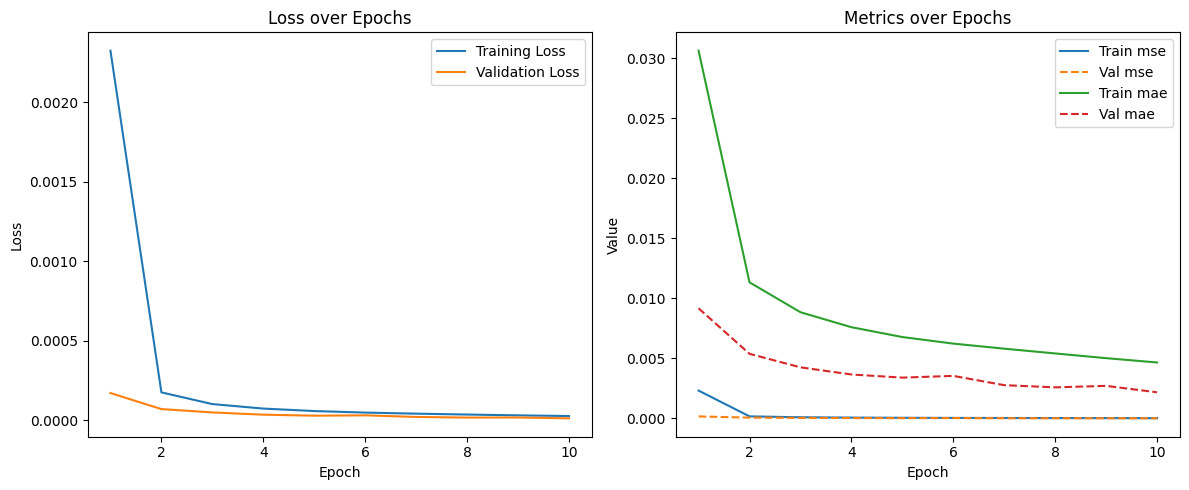

'/Users/steven/Python-data-SiC/SiC-small-test/model/unet_SiC-small-test_20251129_191123_history_data.jpg'

In [ ]:
# Save training history
history_data_file_path = m.save_history(history, model_path=model_path, model_name=model_name, model_train_time=model_train_time)
#history_data_file_path=model_path+'/'+model_name+'_'+model_train_time+'_history_data.dat'
m.plot_history_from_file(file_path=history_data_file_path,
                            loss_name='loss', 
                            val_loss_name='val_loss', 
                            metric_names=['mse', 'mae'], 
                            val_metric_names=['val_mse', 'val_mae'],
                            dpi=150,
                            show_plot=True)

### Extract Latent Features

In [ ]:
dp.delete_data_folders(
    job_data_path, 
    subdirectories='latent_features',
    override=True)

Deleted: /Users/steven/Python-data-SiC/SiC-small-test/latent_features
All specified folders have been successfully deleted.


In [ ]:
# Load the trained autoencoder model
autoencoder_model = m.load_model(model_path, model_name=model_name)

Model loaded from: /Users/steven/Python-data-SiC/SiC-small-test/model/unet_SiC-small-test.keras


In [ ]:
# Training data - tensorflow data pipeline 
train_files, num_train = dp.list_files_by_extension(windows_train_path, 'npy')
train_files = train_files[:train_data_limit]

train_dataset = m.create_tf_dataset_batched(
    train_files, 
    batch_size=cluster_batch_size, 
    buffer_size=cluster_buffer_size, 
    window_size=window_size,
    is_autoencoder=True, 
    shuffle=True)

Found 708 files with extension 'npy' in directory:
/Users/steven/Python-data-SiC/SiC-small-test/windows/train
Data pipeline created with 708 files, batch size: 5120, window size: 16
Sample batch shape: (5120, 16, 16, 1)



In [ ]:
m.extract_latent_features_to_disk_from_prebatched_windows(
    autoencoder_model, 
    train_dataset, 
    latent_features_path, 
    bottleneck_layer_name='bottleneck',
    features_name='latent_features_train',
    return_array=False,
    verbose=False)

....................................................................................................
All latent features have been saved to /Users/steven/Python-data-SiC/SiC-small-test/latent_features.
Sample batch shape: (5120, 1024)


### Train KMEANS using latent features saved to disk

In [ ]:
# List and sort latent feature files
latent_features_files, num_latent_files = dp.list_files_by_extension(latent_features_path, 'npy')

Found 100 files with extension 'npy' in directory:
/Users/steven/Python-data-SiC/SiC-small-test/latent_features


In [ ]:
# Load the latent features from disk into a tensor dataset pipeline
latent_features_dataset = m.create_latent_features_tf_dataset(
    latent_features_files,
    batch_size=cluster_batch_size,
    shuffle=True, 
    shuffle_buffer_size=cluster_buffer_size)

Data pipeline created with 100 files, batch size: 5120
Shuffling enabled with buffer size: 25600
Batch shape: (5120, 1024)


Batch 1 processed. Inertia: 183.2678985595703
Batch 2 processed. Inertia: 173.41094970703125
Batch 3 processed. Inertia: 187.99510192871094
Batch 4 processed. Inertia: 181.22056579589844
Batch 5 processed. Inertia: 186.29237365722656
Batch 6 processed. Inertia: 174.61297607421875
Batch 7 processed. Inertia: 177.37081909179688
Batch 8 processed. Inertia: 180.531982421875
Batch 9 processed. Inertia: 183.6160125732422
Batch 10 processed. Inertia: 179.19485473632812
Batch 11 processed. Inertia: 173.0443572998047
Batch 12 processed. Inertia: 186.53231811523438
Batch 13 processed. Inertia: 183.18728637695312
Batch 14 processed. Inertia: 183.0136260986328
Batch 15 processed. Inertia: 180.62110900878906
Batch 16 processed. Inertia: 179.5885009765625
Batch 17 processed. Inertia: 184.59844970703125
Batch 18 processed. Inertia: 184.8262176513672
Batch 19 processed. Inertia: 173.5576629638672
Batch 20 processed. Inertia: 179.13841247558594
Batch 21 processed. Inertia: 181.12493896484375
Batch 22 p

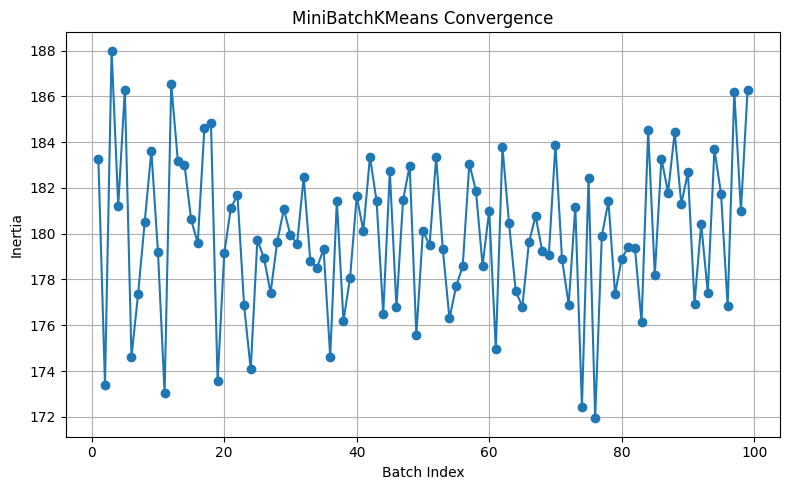

Cluster model saved at: /Users/steven/Python-data-SiC/SiC-small-test/cluster_model/unet_SiC-small-test_kmeans.pkl


In [ ]:

cluster_model, convergence_history = m.train_kmeans(
    latent_features_dataset,                # tf.data.Dataset containing batches of latent feature vectors.
    batch_size=cluster_batch_size,          # Size of each batch for the KMeans model (controls memory usage and stability).
    num_clusters=num_clusters,              # Desired number of clusters (centroids) to form in the data.
    max_iter=5000000,                      # Maximum iterations allowed for each mini-batch to refine centroids.
    reassignment_ratio=0.01   # Fraction of clusters reassigned per step; lower values stabilize updates.
)
# Save and plot convergence history
m.plot_kmeans_convergence(convergence_history, cluster_model_path, model_name=cluster_model_name)

# Save cluster model
m.save_cluster_model(cluster_model, cluster_model_path, model_name=cluster_model_name)

### Process Matrix format data to windows for making predictions 

In [ ]:
dp.delete_data_folders(
    job_data_path, 
    subdirectories=['windows/predict','windows-jpg/predict','jpg/predict'],
    override=True)

No target folders found to delete.


In [ ]:
# Prediction data in MTRX format
mtrx_predict_file_list, _ = dp.list_files_by_extension(mtrx_predict_path,'Z_mtrx',verbose=False)

dp.process_mtrx_files(
    mtrx_predict_file_list,
    job_data_path, # save data path
    flatten_method = flatten_method, pixel_density = pixel_density, pixel_ratio = pixel_ratio,
    data_scaling = data_scaling, window_size = window_size, 
    window_pitch = predict_window_pitch,
    save_windows = save_windows,
    save_window_jpgs=save_window_jpgs,
    save_jpg = save_jpg,
    together = together,
    collate = collate,
    verbose = verbose
)

Found 22 files with extension 'Z_mtrx' in directory:
/Users/steven/Python-data-SiC/mtrx/predict
There are 22 files to process
t..t....tt.....tt.t.tt
********************
Conversion complete.
********************



### Make predictions using the trained autoencoder and KMEANS models

In [ ]:
# Load the trained autoencoder
autoencoder_model = m.load_model(model_path, model_name=model_name)

# Load a previously saved cluster model from disk
cluster_model = m.load_cluster_model(cluster_model_path, model_name=cluster_model_name)

Model loaded from: /Users/steven/Python-data-SiC/SiC-small-test/model/unet_SiC-small-test.keras
Cluster model loaded from: /Users/steven/Python-data-SiC/SiC-small-test/cluster_model/unet_SiC-small-test_kmeans.pkl


In [ ]:
# Get the list of image windows files to make predictions on
predict_data_files_list, predict_data_files_num = dp.list_files_by_extension(windows_predict_path,'.npy',verbose=False)
# Get the corresponding image coordimages list file
image_windows_coordinates_file_list , _ = dp.list_files_by_extension(windows_predict_path,'.txt',verbose=False)
image_windows_coordinates_file_list = [
    name for name in image_windows_coordinates_file_list 
    if "coordinates" in name
]

Found 28 files with extension '.npy' in directory:
/Users/steven/Python-data-SiC/SiC-small-test/windows/predict
Found 56 files with extension '.txt' in directory:
/Users/steven/Python-data-SiC/SiC-small-test/windows/predict


In [ ]:
ut.summarize_parameters(['job_name', 'flatten_method', 'pixel_density', 'pixel_ratio', 'data_scaling', 'window_size', 
                      'window_pitch', 'model_name', 'model_train_time', 'batch_size', 'buffer_size', 'learning_rate', 
                      'epochs', 'cluster_model_name', 'cluster_batch_size', 'cluster_buffer_size', 'num_clusters', 
                      'max_iter', 'reassignment_ratio', 'predict_window_pitch', 'mtrx_train_data_limit', 
                      'mtrx_test_data_limit', 'train_data_limit', 'test_data_limit',], save_path=predictions_path)


Saved parameter summary to /Users/steven/Python-data-SiC/SiC-small-test/predictions/parameter_summary_20251129_191200.csv


,Parameter,Value
0,job_name,SiC-small-test
1,flatten_method,poly_xy
2,pixel_density,15.0
3,pixel_ratio,0.3
4,data_scaling,1000000000.0
5,window_size,16
6,window_pitch,8
7,model_name,unet_SiC-small-test
8,model_train_time,20251129_191123
9,batch_size,128


In [ ]:

# Make predictions on the image windows and save the latent features to disk
for prediction_file, coords_file in zip(predict_data_files_list,image_windows_coordinates_file_list):
    # Load the windows for the image as a numpy file
    image_windows = np.load(prediction_file)
    # Load the image window coordinates
    image_windows_coordinates = dp.load_coordinates_file(coords_file)
    # Reconstruct the original image from the loaded image windows
    reconstructed_img = dp.reconstruct_image(image_windows,image_windows_coordinates,window_size)
    
    # Make a tensorflow data pipeline of just the image windows for this image.
    num_windows = image_windows.shape[0]
    print('\n---\nProcessing file {}'.format(os.path.basename(prediction_file)))
   
    # Predictions windows
    predict_dataset = m.create_tf_dataset_batched(
        [prediction_file], 
        batch_size=predictions_batch_size, 
        window_size=window_size,
        is_autoencoder=False, 
        shuffle=False)
   
    # make the latent features for each window using the autoencoder model 
    latent_predict_features, num_latent_predictions = m.extract_latent_features_to_disk_from_prebatched_windows(
        autoencoder_model, 
        predict_dataset, 
        '',                 # we are not saving these predictions to disk so don't need a folder or name
        features_name='',
        return_array=True,
        verbose=False)
    
    # make preductions 
    cluster_predictions = cluster_model.predict(latent_predict_features)
    
    # Build the reconstruction of the predicted cluster label data
    cluster_img = dp.reconstruct_cluster_image(image_windows_coordinates,window_size, cluster_predictions)
    
    # Pad the cluster image to the original image size
    cluster_img = ut.padded_cluster_img = ut.pad_cluster_image(reconstructed_img,cluster_img,window_size)
    image_name = os.path.splitext(os.path.basename(prediction_file))[0]
  
  #  label_stats, background_labels = m.analyse_cluster_labels(cluster_img, large_region_thresh=0.005)
  #  cluster_img = m.relabel_background(cluster_img, background_labels)

    # Save the cluster image to disk
    m.display_reconstructed_and_cluster_images(reconstructed_img,cluster_img,
                                                show_overlay=True,
                                                save_to_disk=True,
                                                output_path=predictions_path,
                                                image_name=image_name,
                                                dpi=150)  
    


---
Processing file default_2016Apr20-114108_STM-STM_Spectroscopy--1_1_BD_all_windows.npy
Not shuffling
Data pipeline created with 1 files, batch size: 32768, window size: 16
Sample batch shape: (20449, 16, 16, 1)
.Combined latent features shape: (20449, 1024)
Image saved to /Users/steven/Python-data-SiC/SiC-small-test/predictions/default_2016Apr20-114108_STM-STM_Spectroscopy--1_1_BD_all_windows.jpg with dpi=150

---
Processing file default_2016Apr20-114108_STM-STM_Spectroscopy--1_1_FD_all_windows.npy
Not shuffling
Data pipeline created with 1 files, batch size: 32768, window size: 16
Sample batch shape: (20449, 16, 16, 1)
.Combined latent features shape: (20449, 1024)
Image saved to /Users/steven/Python-data-SiC/SiC-small-test/predictions/default_2016Apr20-114108_STM-STM_Spectroscopy--1_1_FD_all_windows.jpg with dpi=150

---
Processing file default_2016Apr20-114108_STM-STM_Spectroscopy--3_1_BD_all_windows.npy
Not shuffling
Data pipeline created with 1 files, batch size: 32768, window

In [ ]:
# data = cluster_img

# # Function to display pixel values on click
# def on_click(event):
#     # Check if the click is on the image
#     if event.inaxes:
#         # Get the row and column indices
#         col, row = int(event.xdata + 0.5), int(event.ydata + 0.5)
#         # Get the pixel value
#         pixel_value = data[row, col]
#         print(f"Clicked on ({row}, {col}) with value: {pixel_value}")

# # Plot the image
# fig, ax = plt.subplots(figsize=(10, 8))  # Adjust figsize (width, height) as desired
# cax = ax.imshow(data, cmap='viridis', interpolation='nearest')
# fig.colorbar(cax, ax=ax)
# ax.set_title("Click on the image to get pixel value")

# # Connect the click event to the function
# cid = fig.canvas.mpl_connect('button_press_event', on_click)

# # Show the plot
# plt.show()


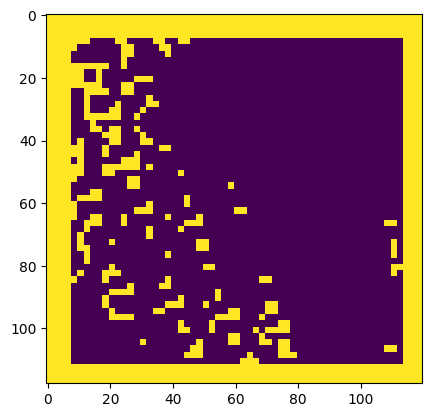

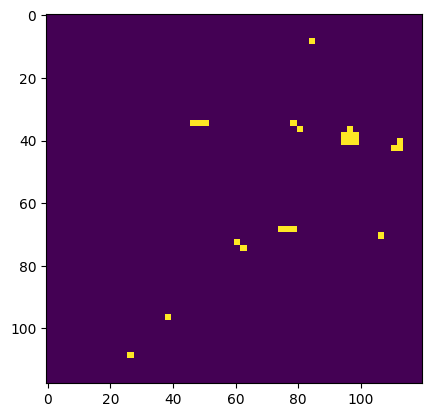

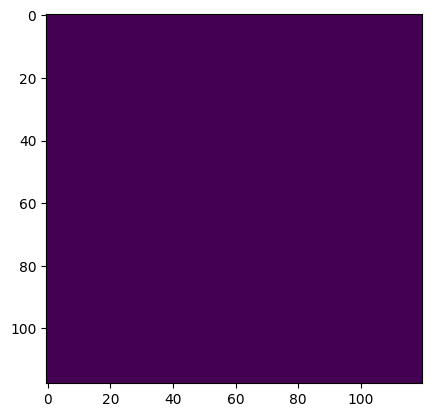

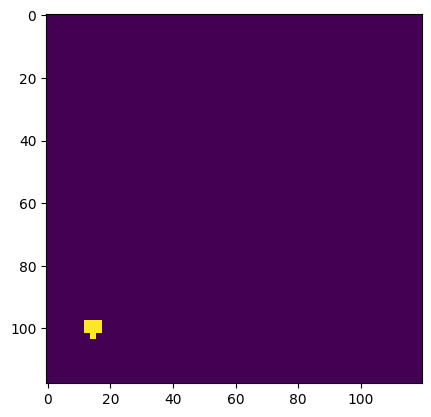

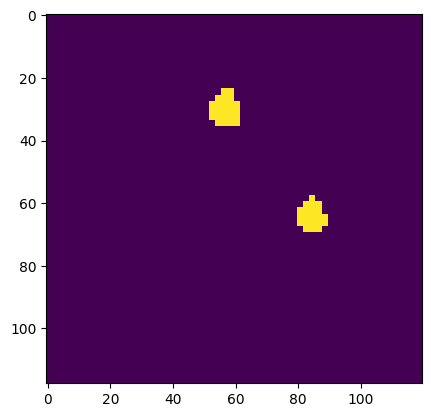

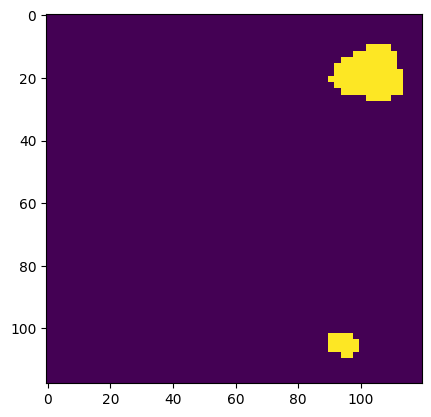

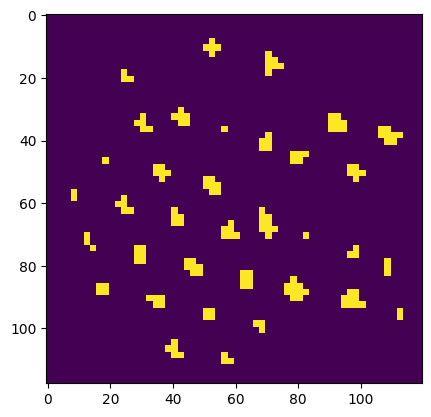

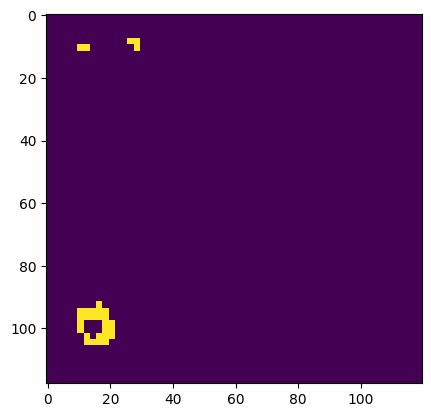

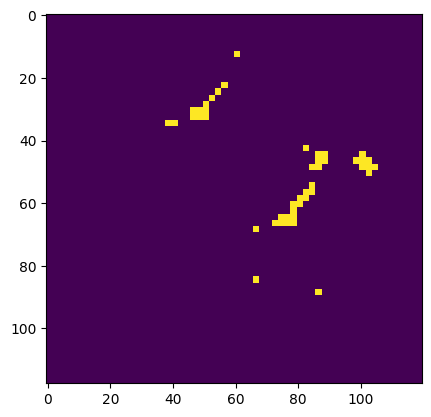

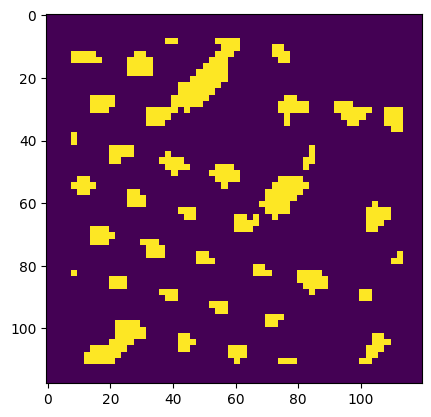

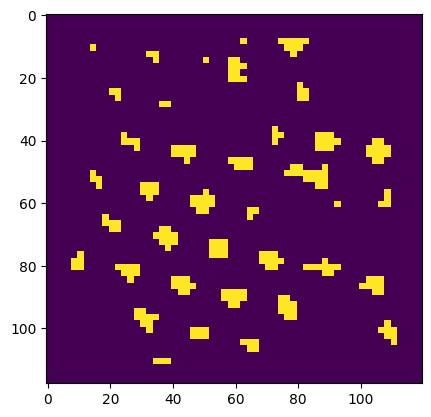

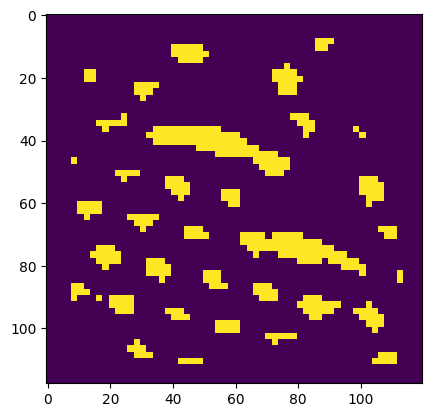

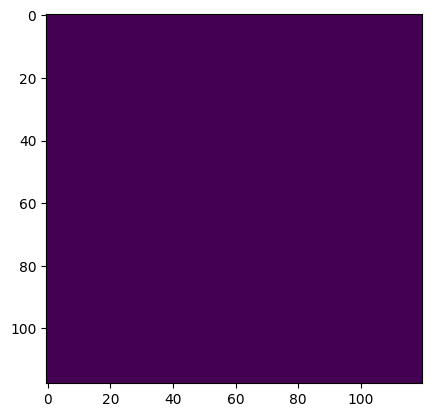

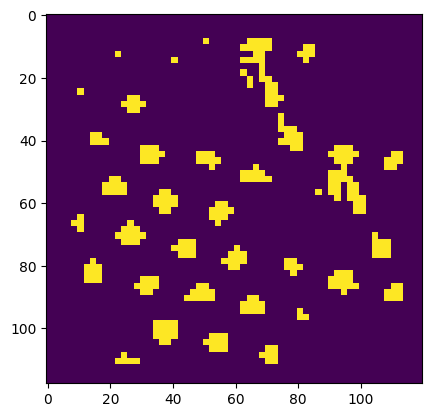

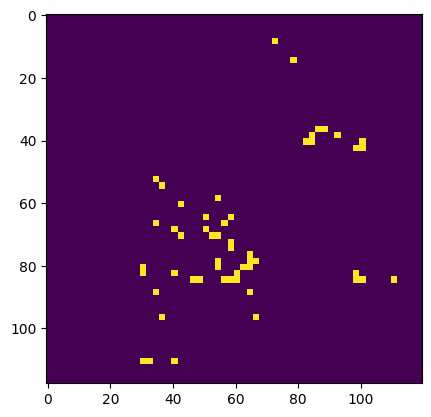

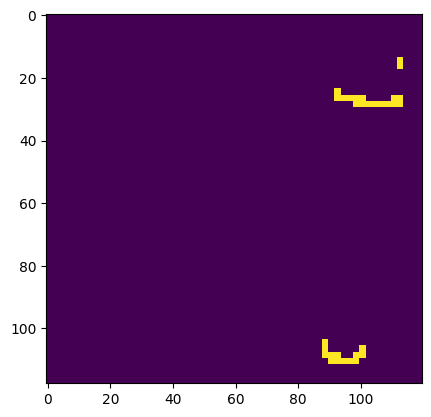

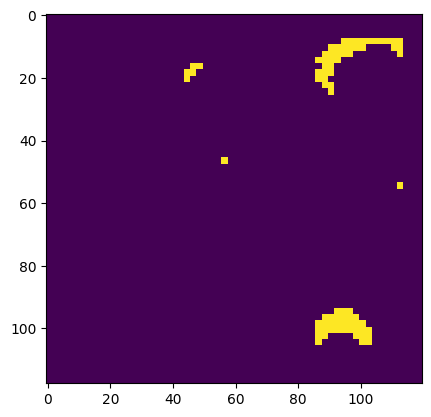

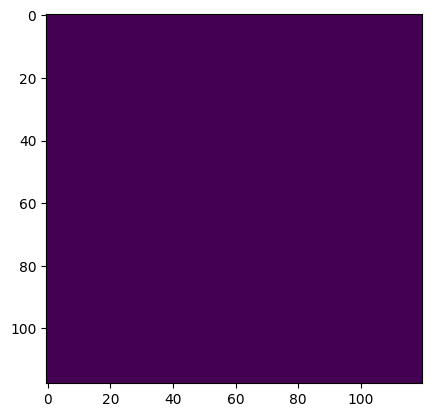

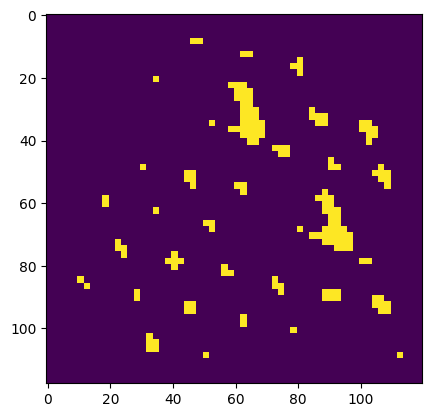

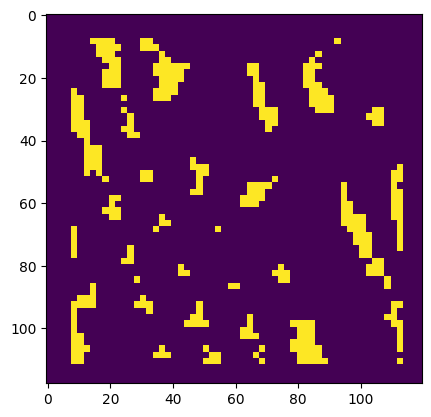

In [ ]:
for i in range(int(np.max(cluster_img))+1):
    plt.imshow(cluster_img==i, cmap='viridis')
    plt.show()